# 01 - Exploração dos Dados
Este notebook carrega o dataset de e-mails e faz uma análise exploratória inicial para entender a distribuição dos dados antes do treinamento dos modelos.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [5]:
df = pd.read_csv('../data/phishing_email.csv')
print(f"Dataset carregado! Shape: {df.shape}")
print(f"\nPrimeiras linhas:")
df.head()

Dataset carregado! Shape: (82486, 2)

Primeiras linhas:


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [6]:
# Exibe a contagem absoluta de cada classe (0 = legítimo, 1 = phishing)
print("Distribuição das classes:")

# value_counts() conta quantas vezes cada valor aparece na coluna 'label'
print(df['label'].value_counts())

print(f"\nPercentual:")

# normalize=True transforma as contagens em proporções (0 a 1), multiplicar por 100 vira percentual
print(df['label'].value_counts(normalize=True) * 100)

Distribuição das classes:
label
1    42891
0    39595
Name: count, dtype: int64

Percentual:
label
1    51.997915
0    48.002085
Name: proportion, dtype: float64


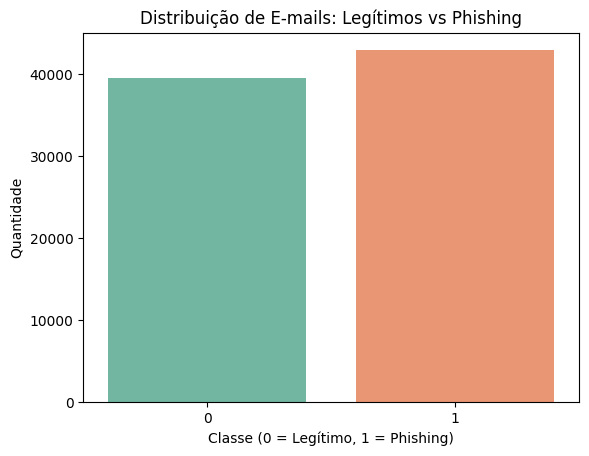

In [12]:
# Cria um gráfico de barras para visualizar a distribuição das classes
sns.countplot(x='label', data=df, hue='label', palette='Set2', legend=False)

# Adiciona título e rótulos nos eixos
plt.title('Distribuição de E-mails: Legítimos vs Phishing')
plt.xlabel('Classe (0 = Legítimo, 1 = Phishing)')
plt.ylabel('Quantidade')

# Exibe o gráfico
plt.show()

In [9]:
# Verifica se existe algum valor vazio no dataset
print("Valores nulos por coluna:")
print(df.isnull().sum())

Valores nulos por coluna:
text_combined    0
label            0
dtype: int64


In [10]:
# Calcula o número de caracteres de cada e-mail
df['tamanho'] = df['text_combined'].apply(len)

# Exibe estatísticas básicas do tamanho
print("Estatísticas do tamanho dos e-mails (em caracteres):")
print(df.groupby('label')['tamanho'].describe())

Estatísticas do tamanho dos e-mails (em caracteres):
         count         mean           std   min    25%    50%     75%  \
label                                                                   
0      39595.0  1536.096098   3695.897909  11.0  411.0  779.0  1493.0   
1      42891.0  1060.413793  21192.696303   1.0  241.0  391.0  1058.0   

             max  
label             
0       160318.0  
1      4279526.0  


In [11]:
# Remove linhas com texto vazio ou nulo
df = df.dropna(subset=['text_combined'])

# Define um limite máximo de caracteres (99.9% dos dados ficam abaixo disso)
limite = df['tamanho'].quantile(0.999)
print(f"Limite de caracteres (percentil 99.9%): {limite:.0f}")

# Remove e-mails acima do limite
df = df[df['tamanho'] <= limite]

print(f"Dataset após limpeza: {df.shape}")
print(f"\nNova distribuição:")
print(df['label'].value_counts())

Limite de caracteres (percentil 99.9%): 40257
Dataset após limpeza: (82403, 3)

Nova distribuição:
label
1    42876
0    39527
Name: count, dtype: int64


In [13]:
# Remove a coluna auxiliar 'tamanho' que criamos para análise
df = df.drop(columns=['tamanho'])

# Salva o dataset limpo para usar nos próximos notebooks
df.to_csv('../data/phishing_email_limpo.csv', index=False)

print("Dataset limpo salvo em data/phishing_email_limpo.csv!")

Dataset limpo salvo em data/phishing_email_limpo.csv!
